# Exploring the EuroSAT dataset

Before training anything, let's look at the data: size, format, class distribution, a visual sample, and pixel statistics (useful for normalization).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torchvision.datasets import EuroSAT

DATA_ROOT = Path("../data")

## Loading and general info

In [2]:
dataset = EuroSAT(root=DATA_ROOT, download=True)

print(f"Number of images: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Classes: {dataset.classes}")

Number of images: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Image format and dimensions

EuroSAT (RGB) is supposed to be uniform in size/format, but it's worth checking rather than assuming.

In [3]:
image, label = dataset[0]
print(f"Type: {type(image)}")
print(f"Size (width, height): {image.size}")
print(f"Mode: {image.mode}")
print(f"First sample's label: {label} ({dataset.classes[label]})")

Type: <class 'PIL.Image.Image'>
Size (width, height): (64, 64)
Mode: RGB
First sample's label: 0 (AnnualCrop)


## Class distribution

A class imbalance can bias the model toward majority classes and make overall accuracy misleading.

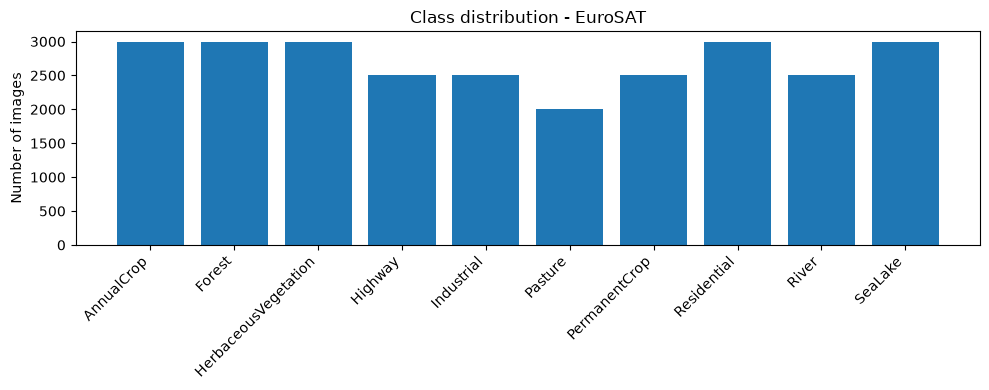

AnnualCrop                 3000
Forest                     3000
HerbaceousVegetation       3000
Residential                3000
SeaLake                    3000
Highway                    2500
Industrial                 2500
PermanentCrop              2500
River                      2500
Pasture                    2000


In [4]:
# dataset.samples is a list of (path, label) — no need to decode images just to count
labels = [label for _, label in dataset.samples]
counts = np.bincount(labels, minlength=len(dataset.classes))
class_counts = dict(zip(dataset.classes, counts))

plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution - EuroSAT")
plt.tight_layout()
plt.show()

for name, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{name:25s} {count:5d}")

## Visual overview: a few samples per class

Useful for spotting visually similar classes (e.g. `River` vs `SeaLake`, `AnnualCrop` vs `PermanentCrop`) that will likely be sources of confusion for the model.

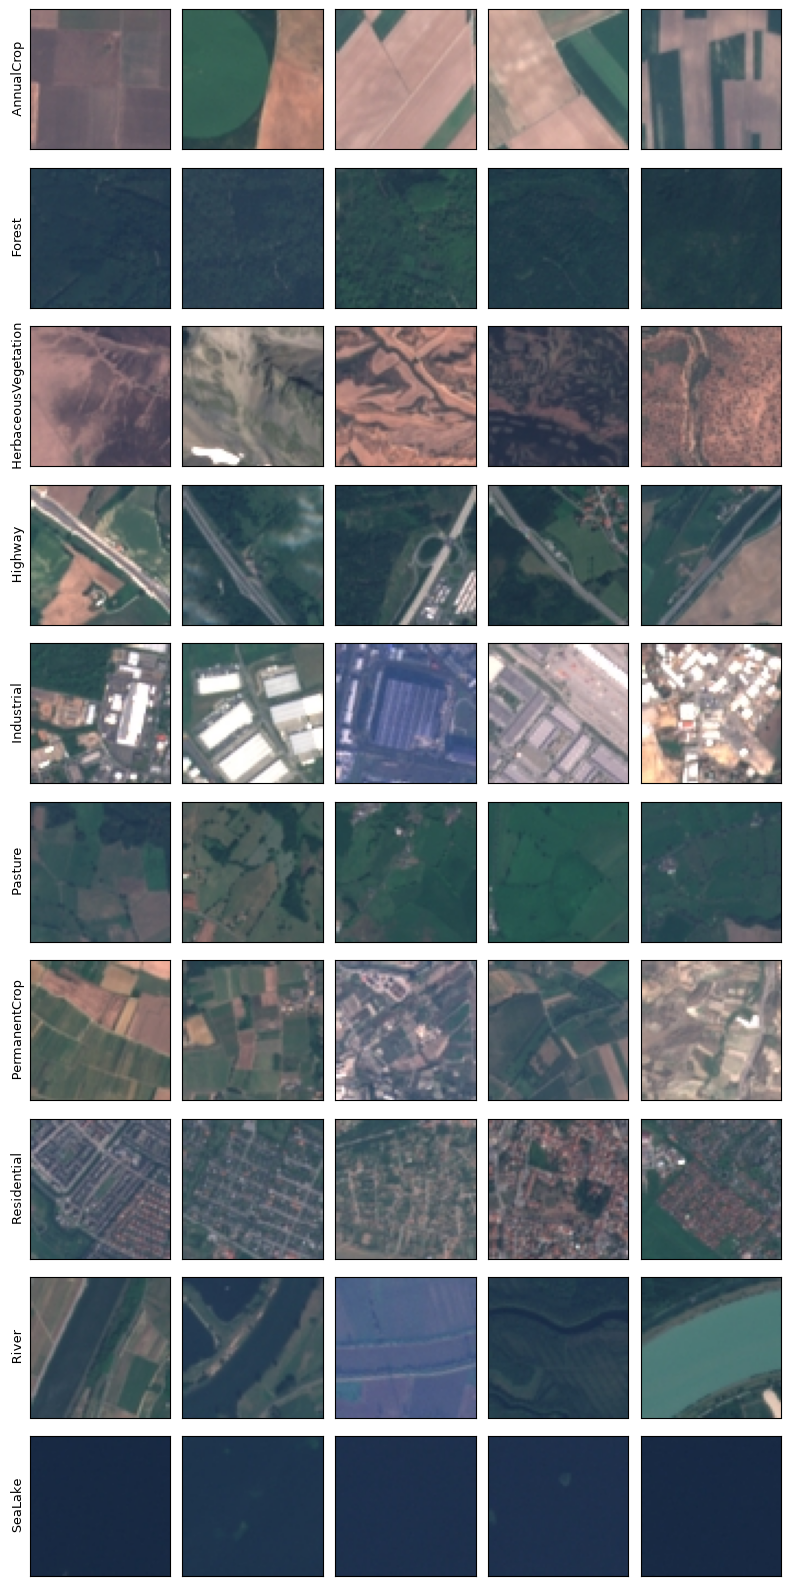

In [5]:
samples_per_class = 5

indices_by_class = {c: [] for c in range(len(dataset.classes))}
for i, (_, label) in enumerate(dataset.samples):
    if len(indices_by_class[label]) < samples_per_class:
        indices_by_class[label].append(i)

fig, axes = plt.subplots(
    len(dataset.classes), samples_per_class,
    figsize=(samples_per_class * 1.6, len(dataset.classes) * 1.6),
)

for class_idx, class_name in enumerate(dataset.classes):
    for col, sample_idx in enumerate(indices_by_class[class_idx]):
        image, _ = dataset[sample_idx]
        ax = axes[class_idx, col]
        ax.imshow(image)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(class_name, fontsize=9)

plt.tight_layout()
plt.show()

## Pixel statistics (per-channel mean/std)

A model pre-trained on ImageNet expects images normalized with ImageNet stats. For fine-tuning, it's often better to recompute stats specific to the dataset (satellite imagery has a different color distribution than natural photos). Computed here on a subsample, which is plenty for the mean/std to stabilize.

In [6]:
to_tensor = transforms.ToTensor()  # PIL -> tensor (C, H, W), values in [0, 1]

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(dataset), size=2000, replace=False)

pixels = torch.stack([to_tensor(dataset[i][0]) for i in sample_indices])
mean = pixels.mean(dim=(0, 2, 3))
std = pixels.std(dim=(0, 2, 3))

print(f"Mean (R, G, B): {mean.tolist()}")
print(f"Std  (R, G, B): {std.tolist()}")

Mean (R, G, B): [0.3447031080722809, 0.3801785111427307, 0.40720677375793457]
Std  (R, G, B): [0.20484785735607147, 0.1395629346370697, 0.11792959272861481]


### Save stats for reuse

These numbers are a fixed property of the dataset, not something to recompute by hand in every notebook that needs them. Saved once here as JSON; `02_train_baseline.ipynb` loads this file instead of hardcoding a copy-pasted value.

In [7]:
import json

STATS_PATH = DATA_ROOT / "eurosat_stats.json"
with open(STATS_PATH, "w") as f:
    json.dump({"mean": mean.tolist(), "std": std.tolist()}, f, indent=2)

print(f"Saved to {STATS_PATH}")

Saved to ../data/eurosat_stats.json


## Next step

Next notebook: train/val/test split, then fine-tuning a pre-trained ResNet on these 10 classes (`02_train_baseline.ipynb`).